Paso 1: Busca un conjunto de datos
Investiga en las diferentes fuentes en línea sobre distintos datasets que podrías utilizar para entrenar un modelo. Puedes utilizar alguna API pública, el repositorio UCI para Machine Learning o el apartado de Kaggle de conjuntos de datos, entre otras muchas fuentes. Recuerda buscar un conjunto de datos simple ya que este no es el proyecto final del curso.


Paso 2: Desarrolla un modelo
Una vez hayas encontrado tu conjunto de datos ideal, analízalo y entrena un modelo. Optimízalo si fuera necesario.

Paso 3: Desarrolla una aplicación web usando Flask
Con los conocimientos adquiridos en este módulo, desarrolla una interfaz para poder utilizar el modelo. Dale el estilo que más te convenga y anota los recursos externos que hayas utilizado para el desarrollo.

Paso 4: Integra el modelo y la aplicación en Render
Crea un servicio gratuito en Render e integra el trabajo que has hecho para poder desplegar la aplicación web en línea. No olvides de incluir el enlace al servicio en tu repositorio.

PASO 1.
Conjunto de datos, se coge un dataset de características de carros usados con su respectivo precio. El precio vendría a ser la variable objetivo.

In [276]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report



from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

df=pd.read_csv("../data/raw/quikr_car.csv",quotechar='"')
df.info()
print("--------------------------------------------------------------------------------------")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        892 non-null    str  
 1   company     892 non-null    str  
 2   year        892 non-null    str  
 3   Price       892 non-null    str  
 4   kms_driven  840 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: str(6)
memory usage: 41.9 KB
--------------------------------------------------------------------------------------


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


Notas:
El dataset contiene valores como nombre de modelo, marca, año, kilómetros y tipo de combustible

Debemos tomar en cuenta que el dataset toma como valores string a todas las variables, esto se ebe revisar posteriormentne para una normalizaicón, ya que precio (variable objetivo) debe estar coomo float.

In [277]:
#revisión de nulos
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

Existen nulos en kilómetros y tipo combustible

In [278]:
#Eliminación de duplicados-------------------
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"El dataset tiene {num_duplicados} filas duplicadas")

#si hubiera filas duplicadas 
#seleccionar duplicados
df_duplicados = df[duplicados]
print("Filas duplicadas:")
print(df_duplicados)

# Eliminar duplicados
#usar el método drop.duplicated() para eliminar filas duplicadas

df = df.drop_duplicates().reset_index(drop=True)

print ("="*80)

print(f"Shape sin duplicados: {df.shape}")


El dataset tiene 94 filas duplicadas
Filas duplicadas:
                                     name   company  year     Price  \
14   Hyundai Santro Xing XO eRLX Euro III   Hyundai  2007    80,000   
15                Mahindra Jeep CL550 MDI  Mahindra  2006  4,25,000   
20                   Mahindra Scorpio S10  Mahindra  2016  3,50,000   
24                 Hyundai i20 Sportz 1.2   Hyundai  2012  1,00,000   
25                 Hyundai i20 Sportz 1.2   Hyundai  2012  1,00,000   
..                                    ...       ...   ...       ...   
626               Tata Sumo Gold EX BS IV      Tata  2012  2,10,000   
641         Maruti Suzuki Swift VDi BS IV    Maruti  2012  2,80,000   
727                   Mahindra Scorpio S4  Mahindra  2015  8,65,000   
861            Hyundai Getz Prime 1.3 GLX   Hyundai  2009  1,15,000   
880    Maruti Suzuki Swift Dzire Tour VDi    Maruti  2009  2,50,000   

     kms_driven fuel_type  
14   45,000 kms    Petrol  
15       40 kms    Diesel  
20   43,

Se eliminaron los duplicados

Revisar los tipos de datos

In [279]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        798 non-null    str  
 1   company     798 non-null    str  
 2   year        798 non-null    str  
 3   Price       798 non-null    str  
 4   kms_driven  748 non-null    str  
 5   fuel_type   745 non-null    str  
dtypes: str(6)
memory usage: 37.5 KB


Normalización de variables

Price

In [280]:
#revisión de los valores de price
df.Price.value_counts()

Price
Ask For Price    33
2,50,000         14
3,50,000         13
1,30,000         12
1,80,000         11
                 ..
39,999            1
50,500            1
5,10,000          1
8,60,000          1
5,00,001          1
Name: count, Length: 274, dtype: int64

Se toma la decisión de normalizar los valores de price, ya que esta será la variable predictora

In [281]:
#normalización de price
#eeliminar ask for price, se eliminan ya que puede ocasionar problemas en el modelo si los cambiamos a null
df = df[df["Price"] != "Ask For Price"]

#Quitar las comas
df["Price"] = df["Price"].str.replace(",", "")

#convertir price a nunmérico
df["Price"] = pd.to_numeric(df["Price"])
df["Price"] = df["Price"].astype(int)
df["Price"].dtype

dtype('int64')

Year

In [282]:
#chequeo de valores
df["year"].unique()

<StringArray>
['2007', '2006', '2014', '2012', '2013', '2016', '2015', '2010', '2017',
 '2008', '2018', '2011', '2019', '2009', '2005', '2000', '150k', 'TOUR',
 '2003', 'r 15', '2004', 'sale', '1995', 'ara)', '2002', 'SELL', '2001',
 'tion', 'odel', '2 bs', 'arry', 'o...', 'Zest', 'ture',  'emi',  'car',
 'able', 'd...', 'SALE', 'sell', 'd Ex', 'n...', 'e...', 'go .', 'k...',
 'o c4', 'zire', 'Sumo',  'cab',  'EV2', 'r...', 'zest']
Length: 52, dtype: str

In [283]:
#convertir a número transformando en nan los valores que no cumplen
df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [284]:
#Revisar vacíos
df["year"].isnull().sum()

np.int64(38)

In [285]:
#eliminar vacíos
df = df.dropna(subset=["year"])

In [286]:
#passar a integer
df["year"] = df["year"].astype(int)

In [287]:
df.info()

<class 'pandas.DataFrame'>
Index: 727 entries, 0 to 797
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        727 non-null    str  
 1   company     727 non-null    str  
 2   year        727 non-null    int64
 3   Price       727 non-null    int64
 4   kms_driven  727 non-null    str  
 5   fuel_type   724 non-null    str  
dtypes: int64(2), str(4)
memory usage: 39.8 KB


 kms_driven

In [288]:
df.kms_driven.value_counts()

kms_driven
45,000 kms      28
35,000 kms      25
55,000 kms      20
50,000 kms      19
60,000 kms      18
                ..
1,46,000 kms     1
1,00,800 kms     1
2,100 kms        1
2,500 kms        1
1,32,000 kms     1
Name: count, Length: 250, dtype: int64

In [289]:
#quitar kms
df["kms_driven"] = df["kms_driven"].str.replace(" kms", "")
#quitar comas
df["kms_driven"] = df["kms_driven"].str.replace(",", "")
#convertir a nunméricos
df["kms_driven"] = pd.to_numeric(
    df["kms_driven"],
    errors="coerce"
)

In [290]:
#Revisar vacíos
df["kms_driven"].isnull().sum()

np.int64(2)

In [291]:
#quitar null
df = df.dropna(subset=["kms_driven"])

fuel_type

In [292]:
#eliminar nulos
df = df.dropna(subset=["fuel_type"])

Se eliminaron registros con valores faltantes en fuel_type debido a que son pocos valores

Dataset final después de limpieza


In [293]:
#resetar indedx
df = df.reset_index(drop=True)


df.info()
print("-"*80)
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        724 non-null    str    
 1   company     724 non-null    str    
 2   year        724 non-null    int64  
 3   Price       724 non-null    int64  
 4   kms_driven  724 non-null    float64
 5   fuel_type   724 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 34.1 KB
--------------------------------------------------------------------------------


name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64

Selección de atributos relevantes


In [294]:
#-------------------------3. Selección de atributos relevantes-------------------
df.drop(["name"], axis = 1, inplace = True)

df.head()

,company,year,Price,kms_driven,fuel_type
0,Hyundai,2007,80000,45000.0,Petrol
1,Mahindra,2006,425000,40.0,Diesel
2,Hyundai,2014,325000,28000.0,Petrol
3,Ford,2014,575000,36000.0,Diesel
4,Ford,2012,175000,41000.0,Diesel


Notas:
Se elimina la variable name porque se puede interpretar que son etiquetas de texto que no pueden impactar en la variable objetivo

Análisis de variables

Precio

In [295]:
df["Price"].describe().apply(lambda x: f"{x:,.0f}")

count          724
mean       403,245
std        480,294
min         30,000
25%        165,000
50%        290,000
75%        489,999
max      8,500,003
Name: Price, dtype: str

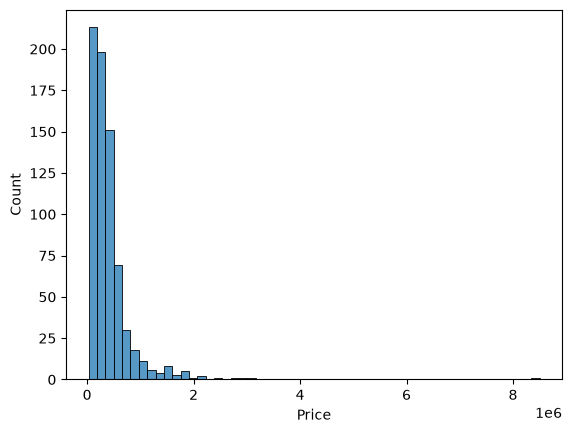

In [296]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Price"])
plt.show()

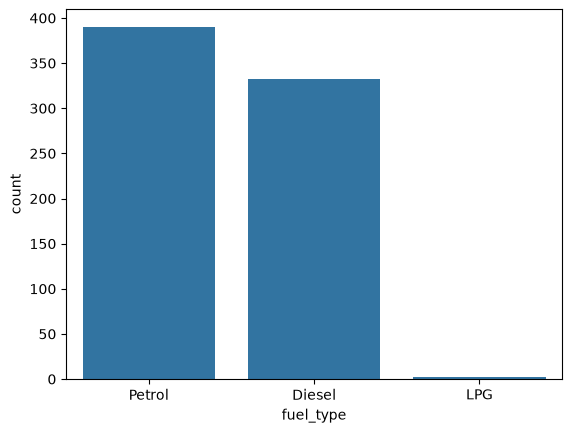

In [297]:
sns.countplot(data=df, x="fuel_type")
plt.show()

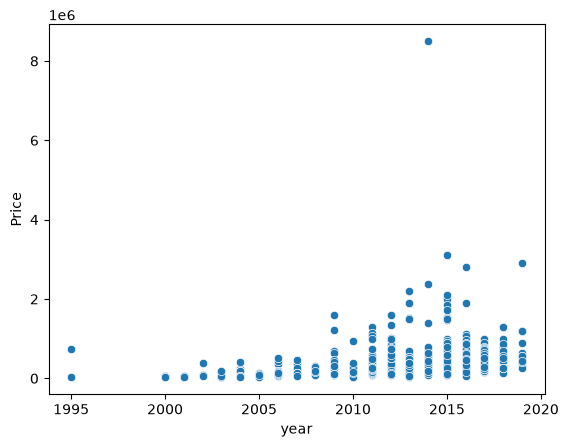

In [298]:
sns.scatterplot(
    data=df,
    x="year",
    y="Price"
)
plt.show()

Conclusiones:
¨Price tiene una distribución asimétrica positiva. La mayoría de los vehículos tienenr angos de precios relativamente bajos.
La mayoría de coches utilizan combustible petrol o diesel

PASO 2. MODELADO

In [299]:
X=df.drop("Price",axis=1)   
y = np.log1p(df["Price"])             #variable objetivo

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.head()

,company,year,kms_driven,fuel_type
446,Maruti,2011,65000.0,Diesel
6,Ford,2016,24530.0,Diesel
423,Maruti,2007,36000.0,Petrol
596,Hyundai,2003,51000.0,Petrol
411,Hyundai,2016,8000.0,Petrol


In [300]:
X_train.shape, X_test.shape

((579, 4), (145, 4))

In [301]:
#ESCALADO   
#variables numéricas
num_variables = [
    "kms_driven","year"
]

In [302]:
# instancio el escalador
scaler = StandardScaler()

# entreno el escalador con los datos de entrenamiento
scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_scal = scaler.transform(X_train[num_variables])
X_train_num_scal = pd.DataFrame(X_train_num_scal, index = X_train.index, columns = num_variables)

X_test_num_scal = scaler.transform(X_test[num_variables])
X_test_num_scal = pd.DataFrame(X_test_num_scal, index = X_test.index, columns = num_variables)

X_train_num_scal.head()

,kms_driven,year
446,0.479840,-0.312828
6,-0.655226,0.924380
423,-0.333526,-1.302593
596,0.087181,-2.292359
411,-1.118844,0.924380


In [303]:
#ENCODING
cat_variables = [
    "company","fuel_type"
]


In [304]:
# instancio el encoder
onehot_encoder = OneHotEncoder(sparse_output=False,handle_unknown="ignore")

# entreno el encoder con los datos de entrenamiento
onehot_encoder.fit(X_train[cat_variables])

# aplico el encoder en amhos
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe, index = X_train.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe, index = X_test.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,company_Audi,company_BMW,company_Chevrolet,company_Datsun,company_Fiat,company_Force,company_Ford,company_Hindustan,company_Honda,company_Hyundai,...,company_Nissan,company_Renault,company_Skoda,company_Tata,company_Toyota,company_Volkswagen,company_Volvo,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol
446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
423,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [305]:
# unificamos el dataset preprocesado hasta el momento
X_train_final = pd.concat([X_train_num_scal, X_train_cat_ohe], axis=1)
X_test_final = pd.concat([X_test_num_scal, X_test_cat_ohe], axis=1)

X_train_final.head()

,kms_driven,year,company_Audi,company_BMW,company_Chevrolet,company_Datsun,company_Fiat,company_Force,company_Ford,company_Hindustan,...,company_Nissan,company_Renault,company_Skoda,company_Tata,company_Toyota,company_Volkswagen,company_Volvo,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol
446,0.479840,-0.312828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,-0.655226,0.924380,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
423,-0.333526,-1.302593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
596,0.087181,-2.292359,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
411,-1.118844,0.924380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [306]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.41520817932478904
RMSE: 0.5882988471501083
R2: 0.5472316373973969


In [307]:
import pickle

pickle.dump(model, open("../data/processed/random_forest_regressor.sav", "wb"))

In [310]:
pickle.dump(
    scaler,
    open("../data/processed/scaler.sav","wb")
)

pickle.dump(
    onehot_encoder,
    open("../data/processed/onehot_encoder.sav","wb")
)

Conclusiones:
El modelo dio un r2 de 0.55

Paso 3: Desarrolla una aplicación web usando Flask

1. datos para formulario

In [311]:
df["company"].unique()

<StringArray>
[   'Hyundai',   'Mahindra',       'Ford',     'Maruti',      'Skoda',
       'Audi',     'Toyota',    'Renault',      'Honda',     'Datsun',
 'Mitsubishi',       'Tata', 'Volkswagen',  'Chevrolet',       'Mini',
        'BMW',     'Nissan',  'Hindustan',       'Fiat',      'Force',
   'Mercedes',       'Land',     'Jaguar',       'Jeep',      'Volvo']
Length: 25, dtype: str

In [ ]:
df["fuel_type"].unique()


<StringArray>
['Petrol', 'Diesel', 'LPG']
Length: 3, dtype: str


Se realizó lo siguiente:
- app.py: para la lógica principal de flask
- index.html: Se añadi ola interfaz gráfica para introducir lso datos y predecir precio de los coches.


Paso 4: Integra el modelo y la aplicación en Render

Se creó un servicio web service en Render conectado al repositorio de github del proyecto.

La configuración utilizada fue:

- Root Directory: src
- Build Command: pip install -r ../requirements.txt
- Start Command: gunicorn app:app

url: https://machine-learning-python-flask-melissahm.onrender.com/

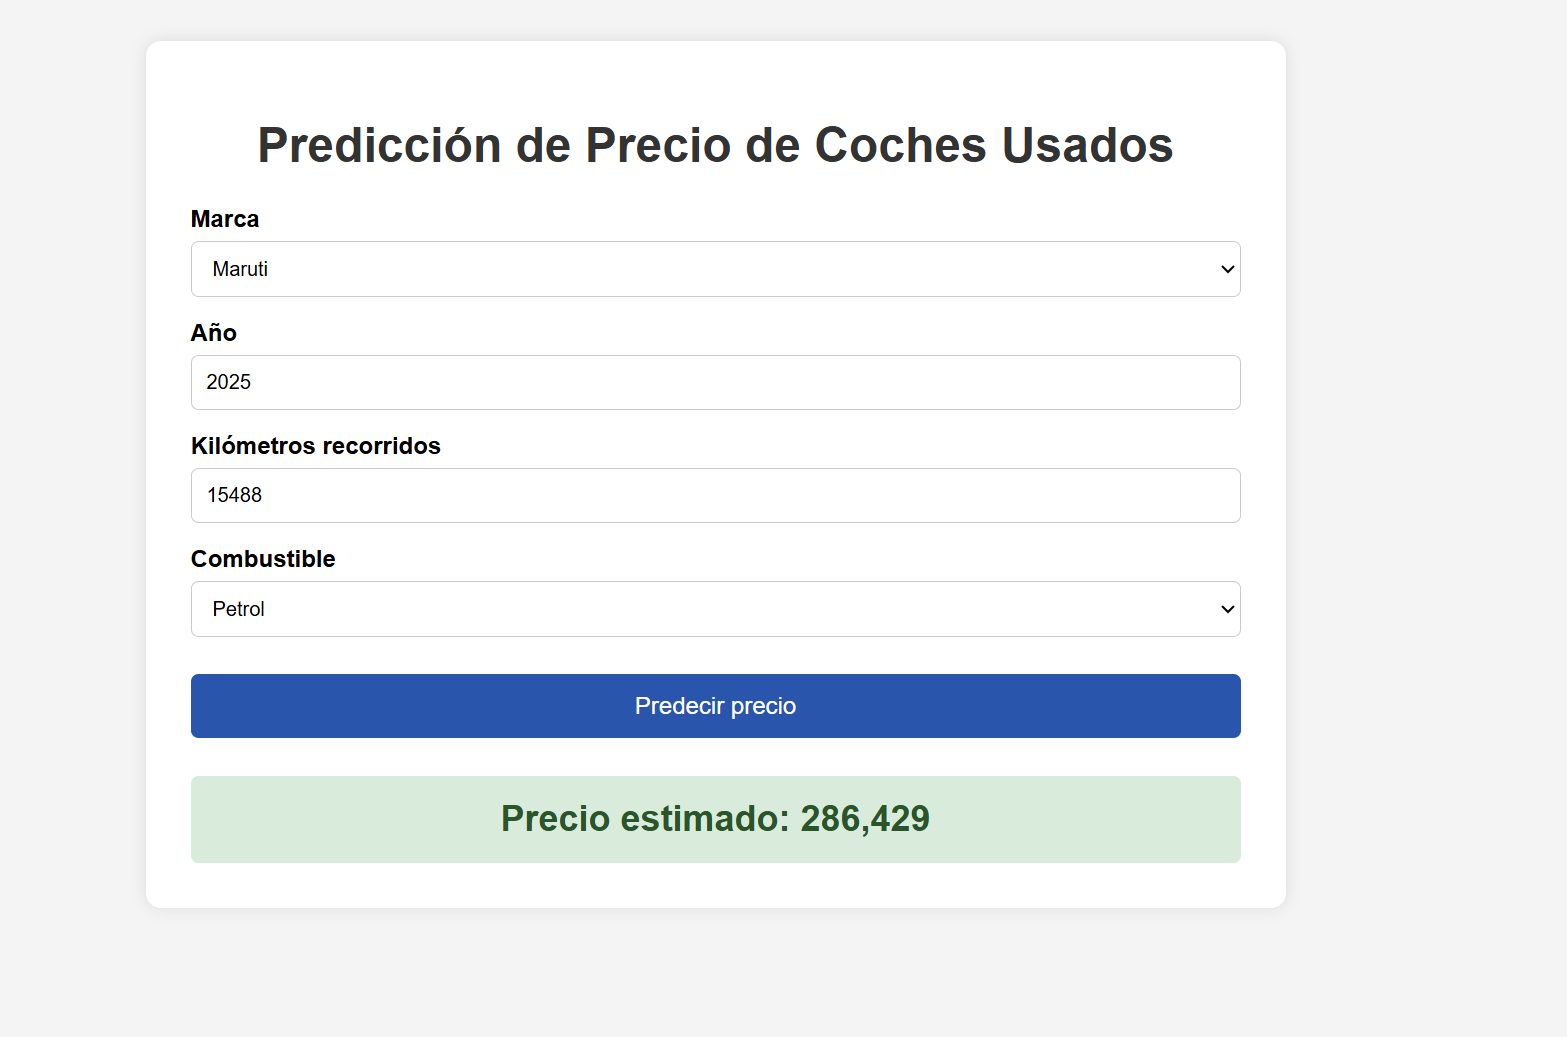